In [4]:
!pip install anndata==0.8.0

  Using cached anndata-0.8.0-py3-none-any.whl (96 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 10.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0
  Attempting uninstall: anndata
    Found existing installation: anndata 0.7.8
    Uninstalling anndata-0.7.8:
      Successfully uninstalled anndata-0.7.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
samap 1.0.2 requires h5py<=2.10, but you have h5py 3.8.0 which is incompatible.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [256]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad
from sklearn.manifold import TSNE

In [ ]:
#input: Full adata and SAM object alongside neuronal adata
#output: Anndata object with low quality clusters removed

In [259]:
cj_dat = sc.read_h5ad('Testing_Raw_Dat_RNASEQ_Joined/tot_dat_AC_ncbi_soupx.h5ad')

In [260]:
cj_dat

AnnData object with n_obs × n_vars = 39788 × 23671
    obs: 'n_counts', 'n_genes', 'key', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'leiden_clusters', 'eq_subclass_nounlabeled', 'region_label', 'neurotransmitter', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [261]:
sam_cj = SAM()
sam_cj.load_data('Active_SAM_joined/SAM_AC_ncbi_soupx.h5ad')
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i

In [262]:
sam_cj.adata.obs['key']

AAACGAAAGGACTGGT    Run12_sample1
AAACGAACAAGAGATT    Run12_sample1
AAAGAACAGTATTGCC    Run12_sample1
AAAGAACCACTTGGCG    Run12_sample1
AAAGAACTCGGCCTTT    Run12_sample1
                        ...      
TTTGTTGTCATATGGC    Run17_sample4
TTTGTTGTCCAAACCA    Run17_sample4
TTTGTTGTCGCAGTCG    Run17_sample4
TTTGTTGTCTACTCAT    Run17_sample4
TTTGTTGTCTTTGCGC    Run17_sample4
Name: key, Length: 39788, dtype: category
Categories (13, object): ['Run12_sample1', 'Run12_sample2', 'Run12_sample3', 'Run12_sample5', ..., 'Run12_sample12', 'Run17_sample2', 'Run17_sample3', 'Run17_sample4']

In [284]:
#Manually set (choose a resolution that clusters the data well)
sam_cj.clustering(param = 1)

In [285]:
sam_cj.adata.obs['leiden_clusters'].nunique()

83

In [286]:
level = 'leiden_clusters'

In [18]:
Xtsne = TSNE(n_components=2, metric = 'cosine').fit_transform(sam_cj.adata.obsm['X_pca'])

/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:827: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  FutureWarning,


In [68]:
sam_cj.adata.obsm['X_tsne'] = Xtsne

NameError: name 'Xtsne' is not defined

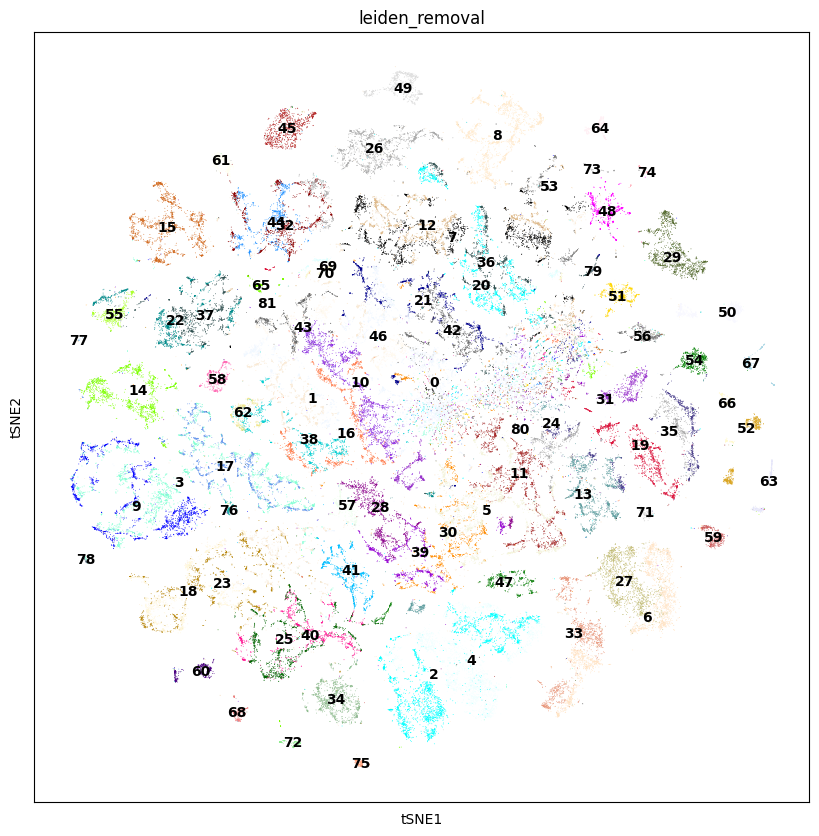

In [20]:
sns.reset_orig()
plt.rcParams['figure.figsize'] = 10,10
sc.pl.tsne(sam_cj.adata, color = 'leiden_removal', palette = list(matplotlib.colors.CSS4_COLORS), legend_loc='on data')

In [289]:
cj_dat.obs[level] = sam_cj.adata.obs[level]

In [ ]:
#look for marker genes
sc.pl.dotplot(cj_dat, ['SLC32A1','SLC17A6','SYT1','MBP'], groupby = 'leiden_clusters')

(0.0, 20000.0)

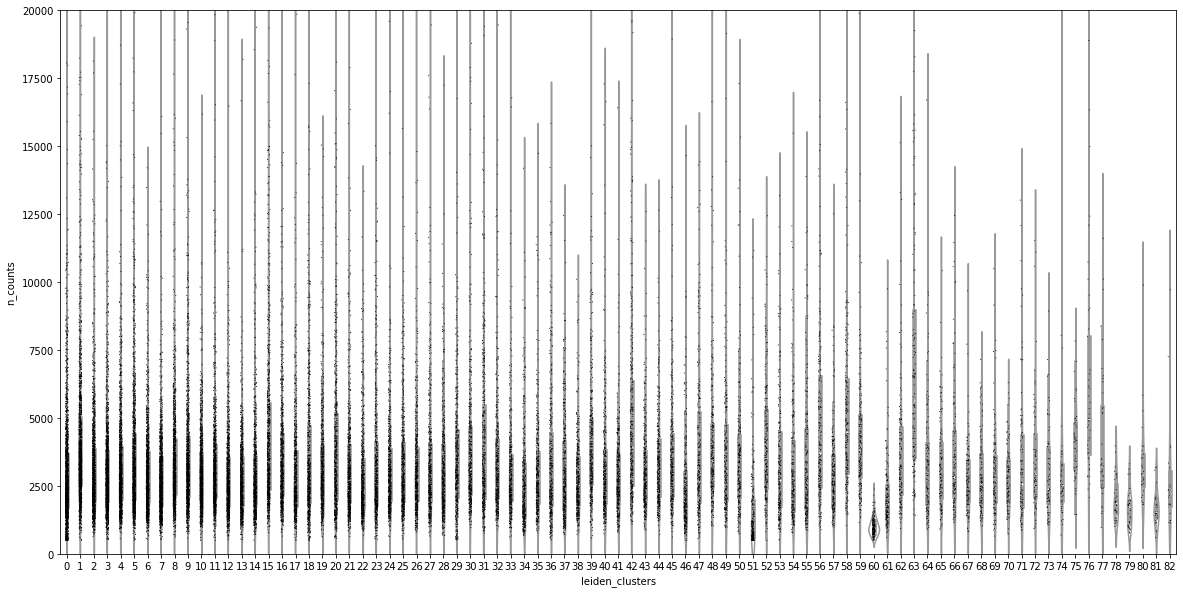

In [290]:
plt.rcParams['figure.figsize'] = 20,10
sns.violinplot(x = 'leiden_clusters', y = 'n_counts', data = cj_dat .obs, color = 'white')
sns.stripplot(x = 'leiden_clusters', y = 'n_counts', data = cj_dat.obs, color = 'black', size = 1)
plt.ylim(0,20000)

(0.0, 7500.0)

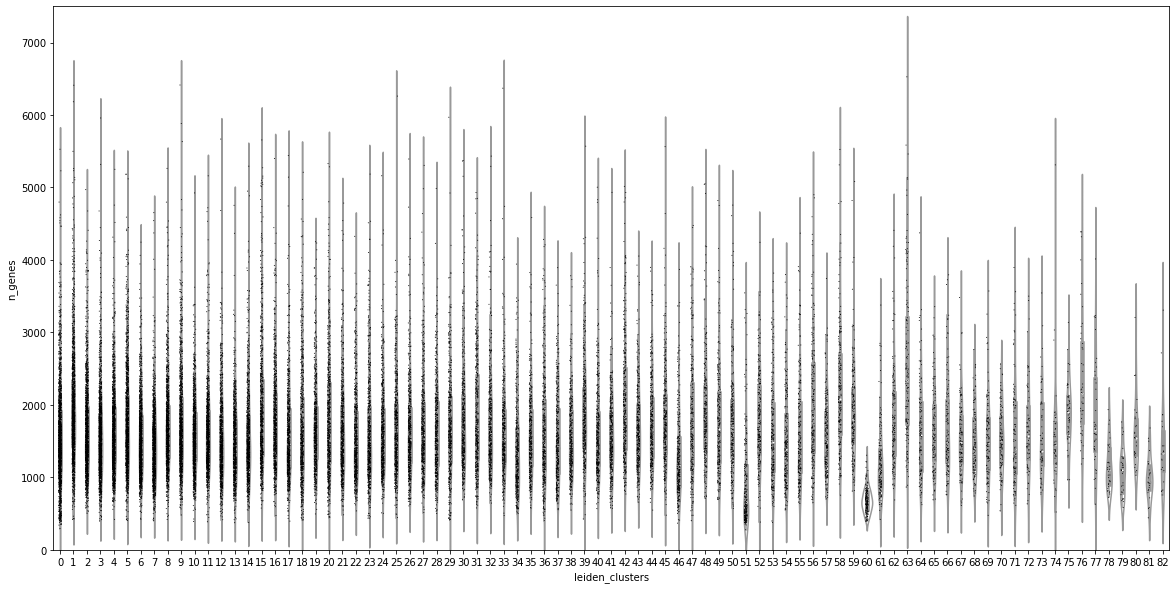

In [291]:
plt.rcParams['figure.figsize'] = 20,10
sns.violinplot(x = 'leiden_clusters', y = 'n_genes', data = cj_dat .obs, color = 'white')
sns.stripplot(x = 'leiden_clusters', y = 'n_genes', data = cj_dat.obs, color = 'black', size = 1)
plt.ylim(0,7500)

In [276]:
ncounts_dict = {}
for item in cj_dat.obs[level].unique():
    val = np.average(cj_dat[cj_dat.obs[level] == item].obs['n_counts'])
    ncounts_dict[item] = val

(array([ 3.,  2.,  1.,  0.,  1.,  4.,  7., 17., 18., 22.,  8.,  3.,  3.,
         3.,  1.,  0.,  1.,  2.,  1.,  2.]),
 array([1004.   , 1272.925, 1541.85 , 1810.775, 2079.7  , 2348.625,
        2617.55 , 2886.475, 3155.4  , 3424.325, 3693.25 , 3962.175,
        4231.1  , 4500.025, 4768.95 , 5037.875, 5306.8  , 5575.725,
        5844.65 , 6113.575, 6382.5  ], dtype=float32),
 <BarContainer object of 20 artists>)

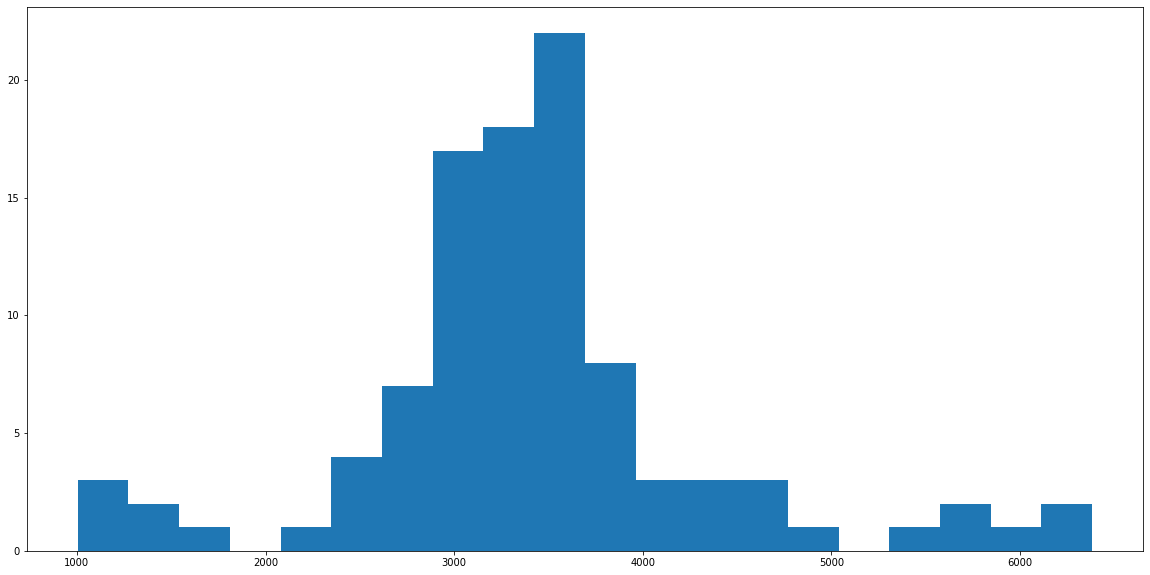

In [269]:
plt.hist(ncounts_dict.values(), bins = 20)

In [89]:
#Manually set based on the histogram
rct = set([i for i in ncounts_dict.keys() if ncounts_dict[i]> 6500] + [i for i in ncounts_dict.keys() if ncounts_dict[i]< 2000])

In [90]:
rct

{58}

In [419]:
#Input your neuronal adata here
dat_NN = sc.read_h5ad('Testing_Raw_Dat_RNASEQ_Joined/tot_dat_AC_ncbi_soupx_neuron_02272025.h5ad')

In [451]:
NN = set(dat_NN.obs_names) & set(cj_dat.obs_names)

In [452]:
test = cj_dat[~cj_dat.obs_names.isin(NN)]
df_counts = (
    test.obs
    .groupby("leiden_clusters", observed=True)
    .size()
    .reset_index(name="n_cells")
)

In [453]:
df_counts = df_counts.set_index('leiden_clusters')

In [454]:
for item in df_counts.index:
    df_counts.loc[item, 'frac'] = df_counts.loc[item, 'n_cells']/len(cj_dat.obs[cj_dat.obs[level] == item])

In [ ]:
df_counts

In [ ]:
#remove subclasses that are entirely within the nonneuronal data
rct - set([46,71])

In [433]:
cleaned_cells_v2 = set(cj_dat[cj_dat.obs[level].isin([54])].obs_names)

In [434]:
a = 0
for item in cleaned_cells_v2:
    if item in sam_test.adata.obs_names:
        a += 1

In [435]:
a

1463

In [436]:
cleaned_adata = cj_dat[~cj_dat.obs_names.isin(cleaned_cells_v2)]

In [437]:
cleaned_adata

View of AnnData object with n_obs × n_vars = 83175 × 19307
    obs: 'n_counts', 'n_genes', 'key', 'leiden_clusters'

In [438]:
cj_dat

AnnData object with n_obs × n_vars = 84652 × 19307
    obs: 'n_counts', 'n_genes', 'key', 'leiden_clusters'

In [439]:
sam_test.adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,n_counts,n_genes,key,subclass_id_label_mapping,subclass_id_label_lc,leiden_clusters,subclass_id_label_mapping_nounlabeled,...,eq_subclass,eq_subclass_lc,eq_subclass_frac,eq_subclass_nounlabeled,NN,ss_subclass,ss_subclass_nounlabeled,ss_subclass_nounlabeled_03102026,ss_subclass_nounlabeled_03102026_crossed,neurotransmitter_v2
AAACCCATCTCAAAGC,MO,11772.0,3844,11772.0,3844,Run12_sample1,Unlabeled,131,61,mo_15,...,Unlabeled,86,1.0,mo_26,Unlabeled,Unlabeled,mo_18,mo_5,107 DMH Hmx2 Gaba,Gaba
AAACGAACAGCACGAA,MO,4877.0,2561,4877.0,2561,Run12_sample1,Unlabeled,290,78,mo_10,...,Unlabeled,240,1.0,mo_7,Unlabeled,Unlabeled,mo_6,mo_0,124 MPN-MPO-PVpo Hmx2 Glut,Glut
AAACGAAGTCGGCACT,MO,5221.0,2859,5221.0,2859,Run12_sample1,108 ARH-PVp Tbx3 Gaba,27,5,108 ARH-PVp Tbx3 Gaba,...,108 ARH-PVp Tbx3 Gaba,16,1.0,108 ARH-PVp Tbx3 Gaba,Neuron,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,Gaba
AAACGAATCCACCCTA,MO,7922.0,3360,7922.0,3360,Run12_sample1,Unlabeled,529,103,mo_9,...,Unlabeled,527,1.0,mo_47,Unlabeled,Unlabeled,mo_38,mo_23,133 PVH-SO-PVa Otp Glut,Glut
AAACGAATCCCAGCGA,MO,7020.0,3204,7020.0,3204,Run12_sample1,128 VMH Fezf1 Glut,104,3,128 VMH Fezf1 Glut,...,128 VMH Fezf1 Glut,333,1.0,128 VMH Fezf1 Glut,Neuron,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTACTAACC,MO,5496.0,2569,5496.0,2569,Run12_sample12,057 NDB-SI-MA-STRv Lhx8 Gaba,217,30,057 NDB-SI-MA-STRv Lhx8 Gaba,...,057 NDB-SI-MA-STRv Lhx8 Gaba,156,1.0,057 NDB-SI-MA-STRv Lhx8 Gaba,Neuron,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,Gaba
TTTGTTGGTCACAATC-1,MO,2974.0,1804,2974.0,1804,Run12_sample12,089 PVR Six3 Sox3 Gaba,204,23,089 PVR Six3 Sox3 Gaba,...,089 PVR Six3 Sox3 Gaba,119,1.0,089 PVR Six3 Sox3 Gaba,Neuron,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,Gaba
TTTGTTGTCCAACCAA,MO,5601.0,2608,5601.0,2608,Run12_sample12,Unlabeled,211,28,mo_11,...,Unlabeled,265,1.0,mo_6,Unlabeled,Unlabeled,mo_4,mo_5,107 DMH Hmx2 Gaba,Gaba
TTTGTTGTCCCTGTTG,MO,6209.0,2759,6209.0,2759,Run12_sample12,Unlabeled,478,57,mo_4,...,Unlabeled,522,1.0,mo_8,Unlabeled,Unlabeled,mo_7,mo_1,mo_1,Glut


In [189]:
cleaned_adata.write_h5ad('Testing_Raw_Dat_RNASEQ_Joined/Backupable/tot_dat_AC_ncbi_soupx_cleaned_03122025.h5ad')